# MIRA: Euclidean/RMSD vs symRMSD metric comparison

Compares the existing MIRA scores (flat unaligned RMSD in normalised coordinate
space) against the new `symrmsd` metric (symmetry-corrected heavy-atom RMSD via
spyrmsd) over the full DiffDock PoseBusters benchmark (305 complexes, 40 samples
each).

Both score sets are loaded from precomputed `.npy` files — no recomputation here.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

DIFFDOCK   = Path('/home/qf226/MProject/DiffDock')
METRICS    = Path('/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2_merged/metrics')
DATA_DIR   = '/home/qf226/rds/hpc-work/data/posebusters_benchmark_set'
sys.path.insert(0, str(DIFFDOCK))

from utils.mira_eval import mira_null
NULL = mira_null(40)
print(f'Null reference (S=40): {NULL:.4f}')

Null reference (S=40): 0.6833


## 1. Load both score sets

In [2]:
old_names  = np.load(METRICS / 'mira_names_rmsd.npy',    allow_pickle=True)
old_scores = np.load(METRICS / 'mira_scores_rmsd.npy',   allow_pickle=True).astype(float)

new_names  = np.load(METRICS / 'mira_names_symrmsd.npy', allow_pickle=True)
new_scores = np.load(METRICS / 'mira_scores_symrmsd.npy',allow_pickle=True).astype(float)

print(f'rmsd-metric  : {len(old_scores)} complexes,  mean = {old_scores.mean():.4f}')
print(f'symrmsd      : {len(new_scores)} complexes,  mean = {new_scores.mean():.4f}')
print(f'null (S=40)  : {NULL:.4f}')

rmsd-metric  : 305 complexes,  mean = 0.6337
symrmsd      : 305 complexes,  mean = 0.6565
null (S=40)  : 0.6833


## 2. Match on shared complexes

In [3]:
old_map = dict(zip(old_names, old_scores))
new_map = dict(zip(new_names, new_scores))
common  = sorted(set(old_map) & set(new_map))

scores_old = np.array([old_map[n] for n in common])
scores_new = np.array([new_map[n] for n in common])
diff       = scores_new - scores_old

print(f'Matched complexes      : {len(common)}')
print(f'  rmsd-metric  mean    : {scores_old.mean():.4f}')
print(f'  symrmsd      mean    : {scores_new.mean():.4f}')
print(f'  null (S=40)          : {NULL:.4f}')
print(f'  Pearson r            : {np.corrcoef(scores_old, scores_new)[0,1]:.3f}')
print(f'  Mean abs difference  : {np.abs(diff).mean():.4f}')
print(f'  Mean signed diff     : {diff.mean():+.4f}  (symrmsd − rmsd)')

Matched complexes      : 305
  rmsd-metric  mean    : 0.6337
  symrmsd      mean    : 0.6565
  null (S=40)          : 0.6833
  Pearson r            : 0.519
  Mean abs difference  : 0.0670
  Mean signed diff     : +0.0228  (symrmsd − rmsd)


## 3. Comparison plots

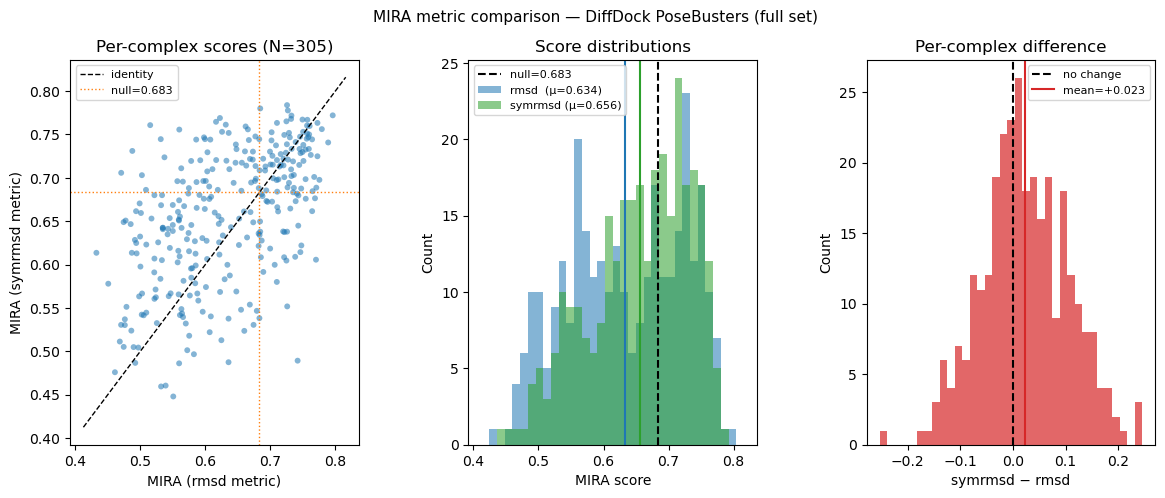

Saved → /home/qf226/MProject/DiffDock/notebooks/mira_metric_comparison.png


In [4]:
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── scatter ──────────────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
ax0.scatter(scores_old, scores_new, s=18, alpha=0.55, edgecolors='none')
lo = min(scores_old.min(), scores_new.min()) - 0.02
hi = max(scores_old.max(), scores_new.max()) + 0.02
ax0.plot([lo, hi], [lo, hi], 'k--', lw=1, label='identity')
ax0.axvline(NULL, color='C1', lw=1, ls=':', label=f'null={NULL:.3f}')
ax0.axhline(NULL, color='C1', lw=1, ls=':')
ax0.set_xlabel('MIRA (rmsd metric)')
ax0.set_ylabel('MIRA (symrmsd metric)')
ax0.set_title(f'Per-complex scores (N={len(common)})')
ax0.legend(fontsize=8)

# ── histograms ────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1])
bins = np.linspace(min(scores_old.min(), scores_new.min()) - 0.02,
                   max(scores_old.max(), scores_new.max()) + 0.02, 35)
ax1.hist(scores_old, bins=bins, alpha=0.55, label=f'rmsd  (μ={scores_old.mean():.3f})',    color='C0')
ax1.hist(scores_new, bins=bins, alpha=0.55, label=f'symrmsd (μ={scores_new.mean():.3f})', color='C2')
ax1.axvline(NULL, color='k', lw=1.5, ls='--', label=f'null={NULL:.3f}')
ax1.axvline(scores_old.mean(), color='C0', lw=1.5, ls='-')
ax1.axvline(scores_new.mean(), color='C2', lw=1.5, ls='-')
ax1.set_xlabel('MIRA score')
ax1.set_ylabel('Count')
ax1.set_title('Score distributions')
ax1.legend(fontsize=8)

# ── signed difference ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[2])
ax2.hist(diff, bins=35, color='C3', alpha=0.7)
ax2.axvline(0,          color='k',  lw=1.5, ls='--', label='no change')
ax2.axvline(diff.mean(),color='C3', lw=1.5, ls='-',
            label=f'mean={diff.mean():+.3f}')
ax2.set_xlabel('symrmsd − rmsd')
ax2.set_ylabel('Count')
ax2.set_title('Per-complex difference')
ax2.legend(fontsize=8)

fig.suptitle('MIRA metric comparison — DiffDock PoseBusters (full set)', fontsize=11)
out = DIFFDOCK / 'notebooks' / 'mira_metric_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

## 4. Sanity checks

In [5]:
print('=== Sanity checks ===')
print(f'All symrmsd scores finite      : {np.all(np.isfinite(scores_new))}')
print(f'symrmsd scores in [0.3, 1.1]   : {np.all((scores_new >= 0.3) & (scores_new <= 1.1))}')
print(f'Pearson r(rmsd, symrmsd)        : {np.corrcoef(scores_old, scores_new)[0,1]:.3f}')
print()

idx_sorted = np.argsort(np.abs(diff))[::-1]
print('Top-10 complexes by |symrmsd − rmsd|:')
for k in idx_sorted[:10]:
    print(f'  {common[k]:20s}  rmsd={scores_old[k]:.4f}  symrmsd={scores_new[k]:.4f}  Δ={diff[k]:+.4f}')

=== Sanity checks ===
All symrmsd scores finite      : True
symrmsd scores in [0.3, 1.1]   : True
Pearson r(rmsd, symrmsd)        : 0.519

Top-10 complexes by |symrmsd − rmsd|:
  7ZU2_DHT              rmsd=0.7420  symrmsd=0.4892  Δ=-0.2528
  7EBG_J0L              rmsd=0.5153  symrmsd=0.7608  Δ=+0.2455
  7XFA_D9J              rmsd=0.4877  symrmsd=0.7310  Δ=+0.2433
  7JY3_VUD              rmsd=0.4706  symrmsd=0.7058  Δ=+0.2351
  7KC5_BJZ              rmsd=0.5315  symrmsd=0.7446  Δ=+0.2131
  8AY3_OE3              rmsd=0.5025  symrmsd=0.7031  Δ=+0.2006
  7DUA_HJ0              rmsd=0.5600  symrmsd=0.7556  Δ=+0.1956
  7NU0_DCL              rmsd=0.5372  symrmsd=0.7237  Δ=+0.1865
  7CL8_TES              rmsd=0.4325  symrmsd=0.6136  Δ=+0.1811
  8AIE_M7L              rmsd=0.5088  symrmsd=0.6862  Δ=+0.1774


In [6]:
# Spot-check: raw symRMSD distances for the most-changed complex
from utils.tarp_eval import load_crystal_coords, load_sample_coords, compute_rmsd_symmetry, build_results_index

RESULTS_DIR = '/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2'
results_index = build_results_index(RESULTS_DIR)

demo_id = common[idx_sorted[0]]
print(f'Spot-checking: {demo_id}  (Δ = {diff[idx_sorted[0]]:+.4f})')

crystal_mol, all_crystal = load_crystal_coords(demo_id, DATA_DIR)
crystal_coords = all_crystal[0]
sample_coords  = load_sample_coords(demo_id, results_index)
print(f'  {len(sample_coords)} predicted poses, {crystal_mol.GetNumAtoms()} heavy atoms')

rmsds = compute_rmsd_symmetry(crystal_mol, crystal_coords, sample_coords[:5])
print(f'  symRMSD(crystal, sample_1..5): {np.round(rmsds, 3)}')

Spot-checking: 7ZU2_DHT  (Δ = -0.2528)


  40 predicted poses, 21 heavy atoms


  symRMSD(crystal, sample_1..5): [0.385 0.383 0.385 0.37  0.386]
